# Optimization: Driving a Case Toward a Design Target

Optimization couples simulation runs in a closed loop where each evaluation depends on previous results. Here, we tune the diffusivity `DT` in the `pitzDaily` case to drive scalar transport toward a design target.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

import uqtopus as uqt

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1. The simulator as a callable

`OpenFOAMSimulator` wraps the case template and solver execution into a Python callable `run(params)` that returns an `xr.Dataset`.

In [ ]:
PARAM_KEY = 'constant__transportProperties__DT'

sim = uqt.OpenFOAMSimulator(
    template_path="templates/scalarTransportFoam",
    solver_script="Allrun",
    output_path="experiments/optimization",
    qoi_variables=["T"],
    qoi_times=["0.1"]
)
sim

## 2. Quantity of interest (QoI)

In optimization, the Quantity of Interest (QoI) defines the scalar design objective extracted from the field, here the domain-averaged concentration (`mean_T`). Because transport physics produces a non-monotonic response with a mixing peak between recirculation entrapment and early outlet breakthrough, the optimizer navigates a nonlinear design space.

In [ ]:
def mean_T(ds):
    """Domain-averaged scalar at the final stored time."""
    return float(ds['T'].values[-1].mean())

## 3. Mapping the design space

A coarse sweep identifies the reachable range of the QoI before launching the optimizer, ensuring the design target is physically achievable.

In [ ]:
DT_LOW, DT_HIGH = 0.01, 0.3

dt_sweep = np.geomspace(DT_LOW, DT_HIGH, 8)
datasets_sweep = [sim.run({PARAM_KEY: float(dt)}) for dt in dt_sweep]
qoi_sweep = np.array([mean_T(ds) for ds in datasets_sweep])

for dt, qoi in zip(dt_sweep, qoi_sweep):
    print(f"DT = {dt:.4f} -> mean T = {qoi:.4f}")

print(f"\nreachable range: [{qoi_sweep.min():.4f}, {qoi_sweep.max():.4f}]")

In [ ]:
TARGET = 0.97

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(dt_sweep, qoi_sweep, 'o-', color='tab:blue', linewidth=1.5, markersize=5, label='Sweep')
ax.axhline(TARGET, color='tab:red', linestyle='--', linewidth=1, label=f'Target ({TARGET})')
ax.axhspan(qoi_sweep.min(), qoi_sweep.max(), color='tab:blue', alpha=0.08, label='Reachable range')
ax.set_xscale('log')
ax.set_xlabel('Diffusivity DT')
ax.set_ylabel('Mean scalar T (t=0.1s)')
ax.set_title('QoI vs Parameter (Coarse Sweep)')
ax.legend(frameon=False, fontsize=8.5, loc='lower right')
plt.show()

In [ ]:
x = datasets_sweep[0].x.values
y = datasets_sweep[0].y.values

fig, axs = plt.subplots(3, 1, figsize=(10, 5.2), sharex=True, sharey=True, constrained_layout=True)

indices = [0, 4, 7]
labels = [
    f"Low DT = {dt_sweep[0]:.4f} (Recirculation zone lags, mean T = {qoi_sweep[0]:.4f})",
    f"Peak DT = {dt_sweep[4]:.4f} (Maximum domain filling, mean T = {qoi_sweep[4]:.4f})",
    f"High DT = {dt_sweep[7]:.4f} (Early outlet breakthrough, mean T = {qoi_sweep[7]:.4f})"
]

for ax, idx, lbl in zip(axs, indices, labels):
    T_field = datasets_sweep[idx]['T'].values[-1]
    cs = ax.tricontourf(x, y, T_field, cmap='RdBu_r', levels=20, vmin=0, vmax=1)
    ax.set_title(lbl, fontsize=9.5)
    for spine in ax.spines.values():
        spine.set_visible(False)

axs[-1].set_xlabel('x [m]')
axs[0].set_xlim([x.min() - 0.005, x.max() + 0.005])
axs[0].set_ylim([y.min() - 0.005, y.max() + 0.005])

cbar = fig.colorbar(cs, ax=axs, fraction=0.02, pad=0.02)
cbar.set_label('T')
plt.show()

## 4. Objective formulation and bounded search

`as_objective` converts the simulation into a minimization problem against the target QoI. Using the sweep to bracket the target restricts the search to a monotonic interval.

In [17]:
crossing = np.flatnonzero(np.diff(np.sign(qoi_sweep - TARGET)))[0]
bounds = (dt_sweep[crossing], dt_sweep[crossing + 1])

qoi_history, dt_history = [], []

def objective(ds):
    qoi = mean_T(ds)
    qoi_history.append(qoi)
    return (qoi - TARGET) ** 2

f = sim.as_objective(metric_fn=objective, param_keys=[PARAM_KEY])

def tracked(dt):
    value = f([dt])
    dt_history.append(dt)
    return value

result = minimize_scalar(tracked, bounds=bounds, method='bounded')

DT_opt = float(result.x)
best = int(np.argmin([(q - TARGET) ** 2 for q in qoi_history]))

print(f"target mean T   {TARGET:.4f}")
print(f"search interval [{bounds[0]:.4f}, {bounds[1]:.4f}]")
print(f"achieved        {qoi_history[best]:.4f}")
print(f"optimal DT      {DT_opt:.4f}")
print(f"simulations     {sim.run_count} ({len(dt_sweep)} sweep, {len(dt_history)} search)")

target mean T   0.9700
search interval [0.0163, 0.0264]
achieved        0.9700
optimal DT      0.0200
simulations     16 (8 sweep, 8 search)


## 5. Search trajectory and solution verification

Tracking the optimization path along the sweep curve and inspecting the final scalar field to verify the converged design.

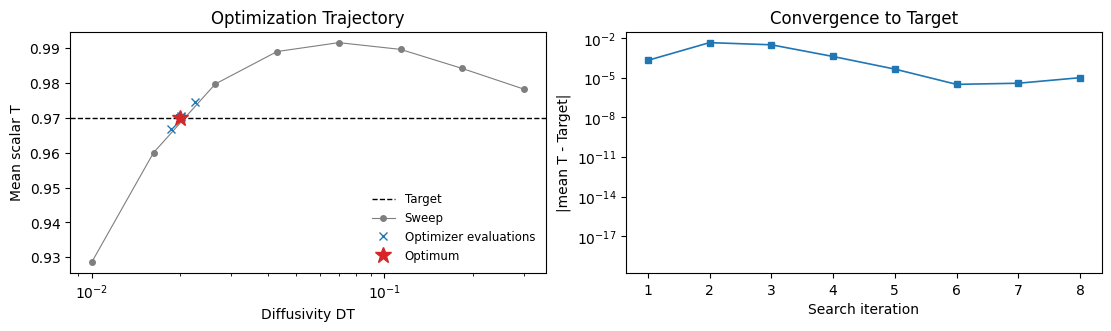

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)

# Search evaluations along the sweep curve
axs[0].axhline(TARGET, color='k', linestyle='--', linewidth=1, label='Target')
axs[0].plot(dt_sweep, qoi_sweep, 'o-', color='tab:gray', markersize=4, linewidth=0.8, label='Sweep')
axs[0].plot(dt_history, qoi_history, 'x', color='tab:blue', markersize=6, label='Optimizer evaluations')
axs[0].plot(DT_opt, qoi_history[best], '*', color='tab:red', markersize=12, label='Optimum')
axs[0].set_xscale('log')
axs[0].set_xlabel('Diffusivity DT')
axs[0].set_ylabel('Mean scalar T')
axs[0].set_title('Optimization Trajectory')
axs[0].legend(frameon=False, fontsize=8.5, loc='lower right')

# Convergence history
errors = [abs(q - TARGET) for q in qoi_history]
axs[1].plot(range(1, len(errors) + 1), errors, 's-', color='tab:blue', markersize=5, linewidth=1.2)
axs[1].axhline(0, color='k', linestyle=':', linewidth=0.8)
axs[1].set_yscale('log')
axs[1].set_xlabel('Search iteration')
axs[1].set_ylabel('|mean T - Target|')
axs[1].set_title('Convergence to Target')

plt.show()

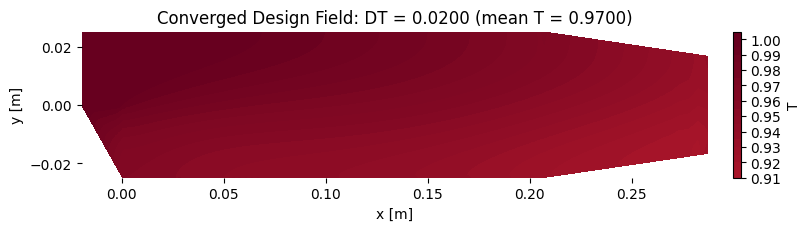

In [19]:
ds_opt = sim.run({PARAM_KEY: DT_opt})
T_opt = ds_opt['T'].values[-1]

fig, ax = plt.subplots(figsize=(8, 2.2), constrained_layout=True)
cs = ax.tricontourf(x, y, T_opt, cmap='RdBu_r', levels=20, vmin=0, vmax=1)
ax.set_title(f'Converged Design Field: DT = {DT_opt:.4f} (mean T = {mean_T(ds_opt):.4f})')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(cs, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('T')
plt.show()